In [3]:
import pandas as pd
import numpy as np

print("Fraud Detection EDA Started 🚀")

Fraud Detection EDA Started 🚀


In [5]:
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\ai-ml project\fraud-detection-mlops\data\raw\credit_card_fraud_10k.csv")

In [6]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (10000, 10)

Columns:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']

Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [8]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [10]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [11]:
print("Target Distribution:")
print(df["is_fraud"].value_counts())

Target Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [12]:
print("Target Distribution (%):")
print(df["is_fraud"].value_counts(normalize=True) * 100)

Target Distribution (%):
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [13]:
df.groupby("is_fraud")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
0,9849,175.333015,122.11,0.00,1471.04
1,151,216.182980,118.94,0.11,1185.07


In [14]:
df.groupby("is_fraud")["transaction_hour"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
is_fraud,,,,
0,11.712154,12.0,0,23
1,3.841060,2.0,0,23


In [15]:
hour_fraud = df.groupby("transaction_hour")["is_fraud"].agg(
    ["count", "sum"]
)

hour_fraud["fraud_rate"] = (
    hour_fraud["sum"] / hour_fraud["count"] * 100
)

hour_fraud

,count,sum,fraud_rate
transaction_hour,,,
0,417,37,8.872902
1,425,34,8.000000
2,385,23,5.974026
3,425,27,6.352941
4,384,1,0.260417
5,419,2,0.477327
6,413,2,0.484262
7,425,0,0.000000
8,424,3,0.707547


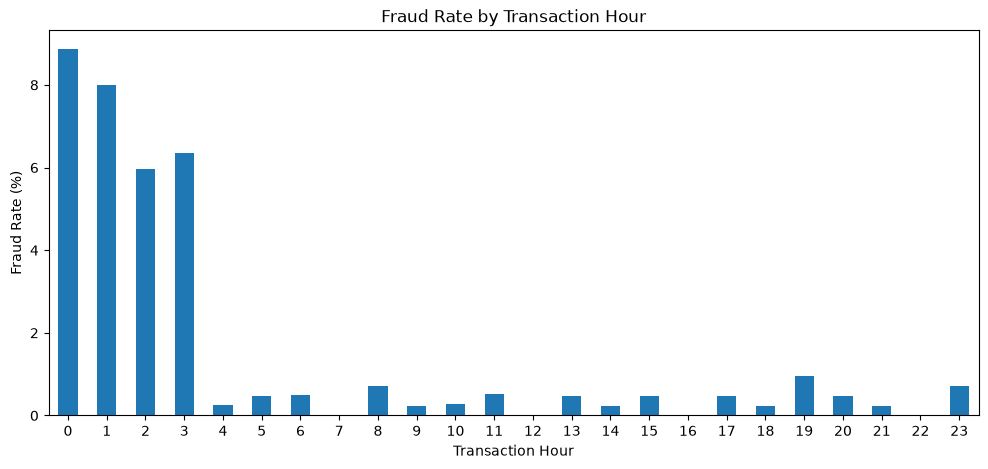

In [16]:
import matplotlib.pyplot as plt

hour_fraud["fraud_rate"].plot(kind="bar", figsize=(12, 5))

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [17]:
merchant_fraud = df.groupby("merchant_category")["is_fraud"].agg(
    ["count", "sum"]
)

merchant_fraud["fraud_rate"] = (
    merchant_fraud["sum"] / merchant_fraud["count"] * 100
)

merchant_fraud.sort_values("fraud_rate", ascending=False)

,count,sum,fraud_rate
merchant_category,,,
Grocery,1944,39,2.006173
Food,2093,35,1.672241
Travel,1990,29,1.457286
Electronics,1923,24,1.248050
Clothing,2050,24,1.170732


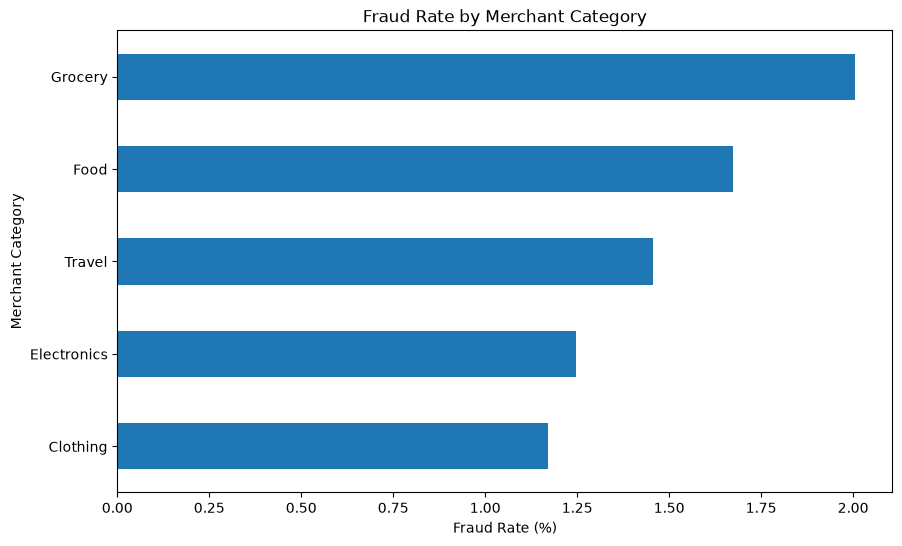

In [18]:
merchant_fraud["fraud_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant Category")
plt.show()

In [19]:
foreign_fraud = df.groupby("foreign_transaction")["is_fraud"].agg(
    ["count", "sum"]
)

foreign_fraud["fraud_rate"] = (
    foreign_fraud["sum"] / foreign_fraud["count"] * 100
)

foreign_fraud

,count,sum,fraud_rate
foreign_transaction,,,
0,9022,69,0.764797
1,978,82,8.384458


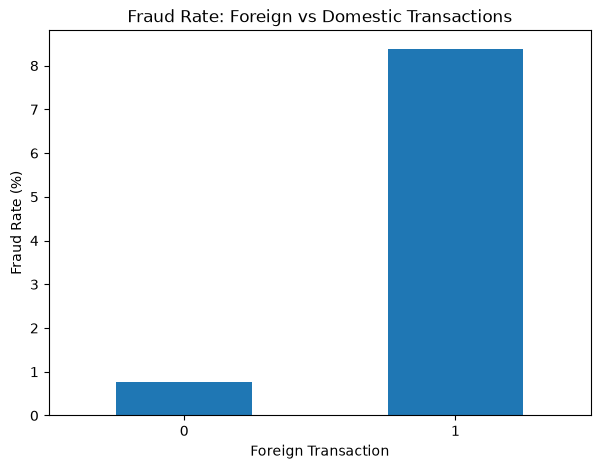

In [20]:
foreign_fraud["fraud_rate"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Fraud Rate: Foreign vs Domestic Transactions")
plt.xlabel("Foreign Transaction")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [21]:
location_fraud = df.groupby("location_mismatch")["is_fraud"].agg(
    ["count", "sum"]
)

location_fraud["fraud_rate"] = (
    location_fraud["sum"] / location_fraud["count"] * 100
)

location_fraud

,count,sum,fraud_rate
location_mismatch,,,
0,9143,79,0.864049
1,857,72,8.401400


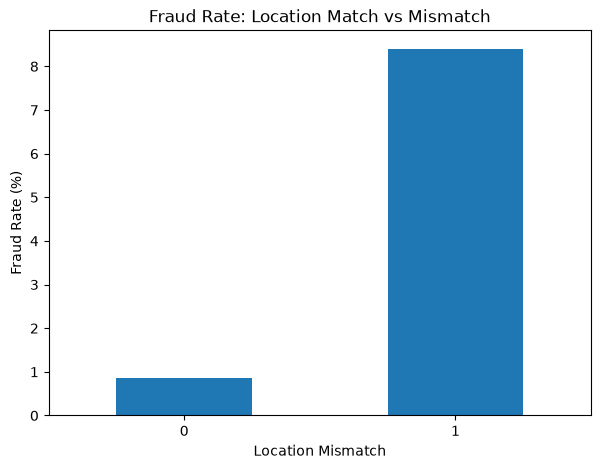

In [22]:
location_fraud["fraud_rate"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Fraud Rate: Location Match vs Mismatch")
plt.xlabel("Location Mismatch")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [23]:
device_fraud = df.groupby("device_trust_score")["is_fraud"].agg(
    ["count", "sum"]
)

device_fraud["fraud_rate"] = (
    device_fraud["sum"] / device_fraud["count"] * 100
)

device_fraud

,count,sum,fraud_rate
device_trust_score,,,
25,130,9,6.923077
26,142,6,4.225352
27,141,10,7.092199
28,132,13,9.848485
29,136,7,5.147059
...,...,...,...
95,142,1,0.704225
96,120,0,0.000000
97,125,0,0.000000


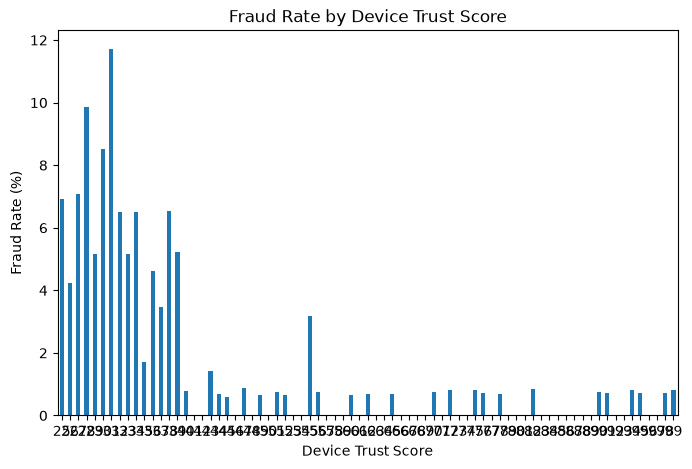

In [24]:
device_fraud["fraud_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Device Trust Score")
plt.xlabel("Device Trust Score")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [25]:
df["device_trust_bin"] = pd.cut(
    df["device_trust_score"],
    bins=[24, 39, 54, 69, 84, 99],
    labels=["25-39", "40-54", "55-69", "70-84", "85-99"]
)

device_bin_fraud = df.groupby(
    "device_trust_bin",
    observed=True
)["is_fraud"].agg(["count", "sum"])

device_bin_fraud["fraud_rate"] = (
    device_bin_fraud["sum"] /
    device_bin_fraud["count"] * 100
)

device_bin_fraud

,count,sum,fraud_rate
device_trust_bin,,,
25-39,1955,122,6.240409
40-54,2072,9,0.434363
55-69,2044,8,0.391389
70-84,2005,6,0.299252
85-99,1924,6,0.311850


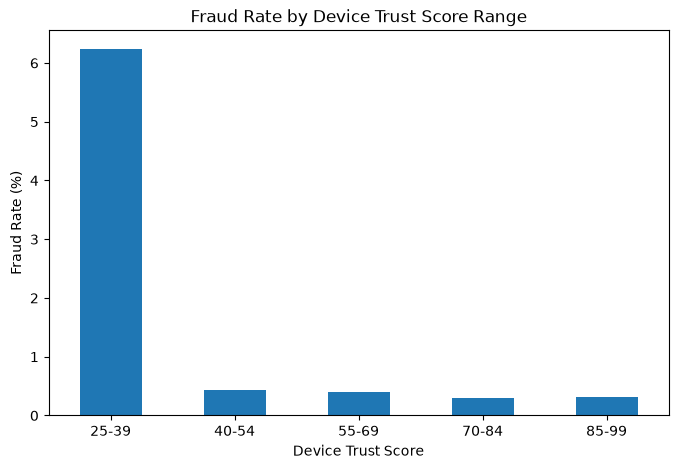

In [26]:
device_bin_fraud["fraud_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Device Trust Score Range")
plt.xlabel("Device Trust Score")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [27]:
velocity_fraud = df.groupby("velocity_last_24h")["is_fraud"].agg(
    ["count", "sum"]
)

velocity_fraud["fraud_rate"] = (
    velocity_fraud["sum"] / velocity_fraud["count"] * 100
)

velocity_fraud

,count,sum,fraud_rate
velocity_last_24h,,,
0,1378,14,1.015965
1,2694,21,0.779510
2,2662,28,1.051841
3,1785,21,1.176471
4,934,10,1.070664
5,365,42,11.506849
6,131,11,8.396947
7,42,4,9.523810
8,6,0,0.000000


In [28]:
df["age_group"] = pd.cut(
    df["cardholder_age"],
    bins=[0, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)

age_fraud = df.groupby("age_group", observed=True)["is_fraud"].agg(
    ["count", "sum"]
)

age_fraud["fraud_rate"] = (
    age_fraud["sum"] / age_fraud["count"] * 100
)

age_fraud

,count,sum,fraud_rate
age_group,,,
18-29,2315,32,1.382289
30-39,1915,30,1.566580
40-49,1936,32,1.652893
50-59,1918,32,1.668405
60+,1916,25,1.304802


In [29]:
interaction = df.groupby(
    ["foreign_transaction", "location_mismatch"]
)["is_fraud"].agg(["count", "sum"])

interaction["fraud_rate"] = (
    interaction["sum"] / interaction["count"] * 100
)

interaction

count  sum  fraud_rate
foreign_transaction location_mismatch                        
0                   0                   8250   26    0.315152
                    1                    772   43    5.569948
1                   0                    893   53    5.935050
                    1                     85   29   34.117647

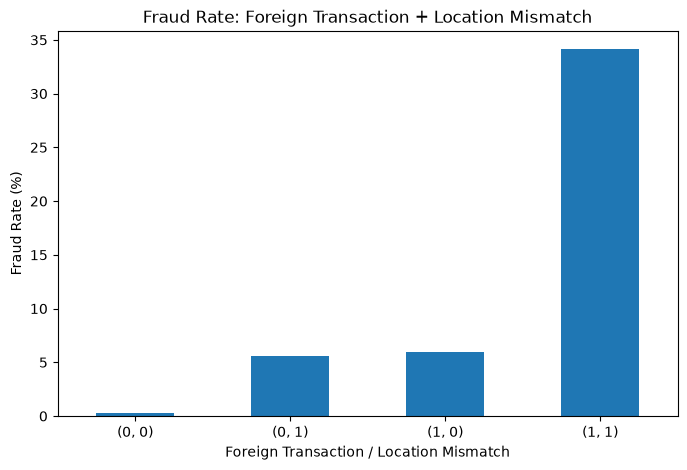

In [30]:
interaction["fraud_rate"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate: Foreign Transaction + Location Mismatch")
plt.xlabel("Foreign Transaction / Location Mismatch")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [31]:
velocity_device = df.groupby(
    ["velocity_last_24h", "device_trust_score"]
)["is_fraud"].agg(["count", "sum"])

velocity_device["fraud_rate"] = (
    velocity_device["sum"] / velocity_device["count"] * 100
)

velocity_device.sort_values("fraud_rate", ascending=False).head(15)

count  sum  fraud_rate
velocity_last_24h device_trust_score                        
7                 78                      1    1  100.000000
                  30                      1    1  100.000000
                  31                      1    1  100.000000
                  34                      1    1  100.000000
6                 90                      1    1  100.000000
                  39                      2    2  100.000000
5                 26                      4    3   75.000000
                  31                      4    3   75.000000
6                 31                      3    2   66.666667
5                 34                      3    2   66.666667
                  32                      2    1   50.000000
6                 38                      2    1   50.000000
                  36                      2    1   50.000000
5                 36                      4    2   50.000000
6                 27                      2    1   50.000000

In [32]:
df["velocity_group"] = pd.cut(
    df["velocity_last_24h"],
    bins=[-1, 2, 4, 6, 10],
    labels=["0-2", "3-4", "5-6", "7-10"]
)

velocity_group_fraud = df.groupby(
    "velocity_group",
    observed=True
)["is_fraud"].agg(["count", "sum"])

velocity_group_fraud["fraud_rate"] = (
    velocity_group_fraud["sum"] /
    velocity_group_fraud["count"] * 100
)

velocity_group_fraud

,count,sum,fraud_rate
velocity_group,,,
0-2,6734,63,0.935551
3-4,2719,31,1.140125
5-6,496,53,10.685484
7-10,51,4,7.843137


In [33]:
numeric_cols = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
    "is_fraud"
]

corr = df[numeric_cols].corr()

corr["is_fraud"].sort_values(ascending=False)

is_fraud               1.000000
foreign_transaction    0.185597
location_mismatch      0.173009
velocity_last_24h      0.103413
amount                 0.028404
cardholder_age        -0.000590
device_trust_score    -0.137913
transaction_hour      -0.138665
Name: is_fraud, dtype: float64